1. Analyze and Preprocess data - Check if the dataset has missing values or has any other problem.
2. Feature Engineering
3. Sampling Your Data
4. Build Model:
- Try DecisionTree
- Try RandomForest
5. Perform model on training set and test set using gridsearch CV
6. Measure performance of the model.
7. Which metric is your main metric for this problem and why? What is your main model as well as their params and why?


How can I measure your point:
1. Your function is callable and runs correctly
2. The performance of your model (in full pipeline) is acceptable.
3. The data preprocessing is correct or make sense
4. The Feature engineering is correct or make sense
5. Any other additional process will be considered a small plus point.

** Submit Link **: https://forms.gle/aAjeG25RPUtQHijs9

Churn rate is a marketing metric that describes the number of customers who leave a business over a specific time period. Every user is assigned a prediction value that estimates their state of churn at any given time. This value is based on:

Age- Age Of The Customer

Employment Type- The Sector In Which Customer Is Employed

GraduateOrNot- Whether The Customer Is College Graduate Or Not

AnnualIncome- The Yearly Income Of The Customer In Indian Rupees[Rounded To Nearest 50 Thousand Rupees]

FamilyMembers- Number Of Members In Customer's Family

ChronicDisease- Whether The Customer Suffers From Any Major Disease Or
Conditions Like Diabetes/High BP or Asthama,etc.

FrequentFlyer- Derived Data Based On Customer's History Of Booking Air Tickets On Atleast 4 Different Instances In The Last 2 Years[2017-2019].

EverTravelledAbroad- Has The Customer Ever Travelled To A Foreign Country[Not Necessarily Using The Company's Services]

TravelInsurance- Did The Customer Buy Travel Insurance Package During Introductory Offering Held In The Year 2019.

## Load Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from google.colab import drive

# drive.mount("/content/drive")

In [4]:
import pandas as pd

df = pd.read_csv(r"D:\ML\tuan4\TravelInsurancePrediction.csv")
df.head()

,Unnamed: 0,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,0,31,Government Sector,Yes,400000,6,1,No,No,0
1,1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


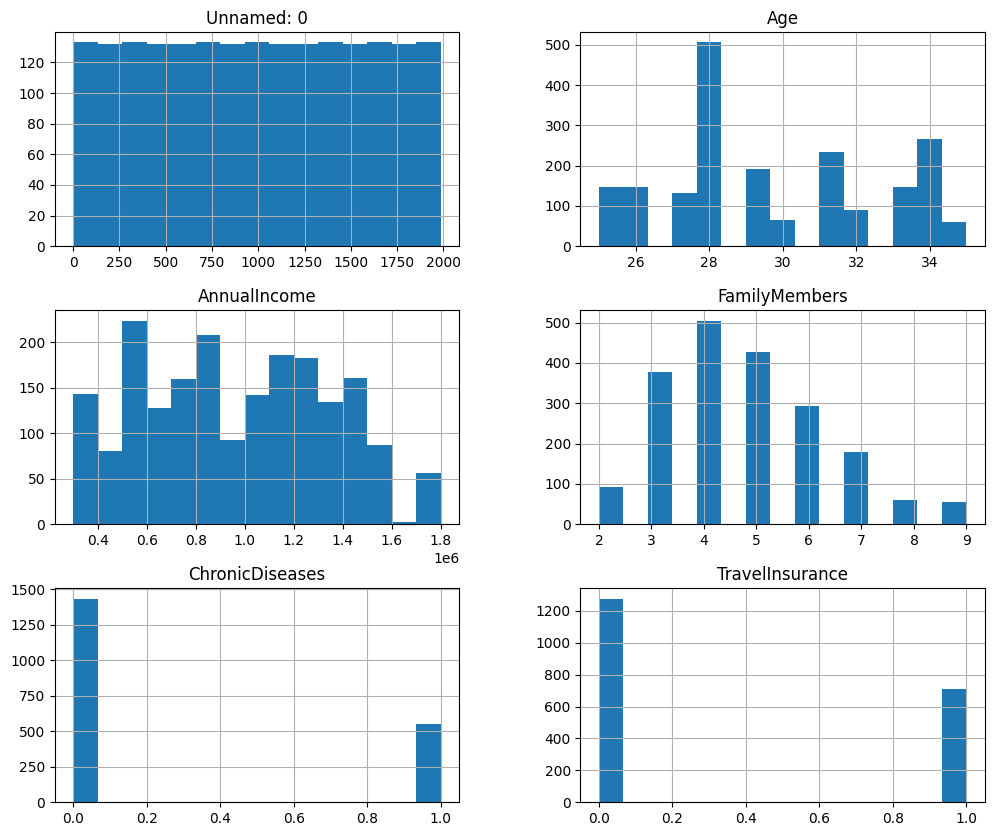

In [5]:
#ToDo: Show histogram of dataframe
df.hist(df.columns, figsize=(12, 10), bins=15)
plt.show()

## Data Analysis

In [6]:
# Get categorical columns and numerical columns
categorical_cols = [feature for feature in df.columns if df[feature].dtype == "O"]
numerical_cols = [feature for feature in df.columns if df[feature].dtype != "O"]

print(numerical_cols)
print(categorical_cols)

['Unnamed: 0', 'Age', 'AnnualIncome', 'FamilyMembers', 'ChronicDiseases', 'TravelInsurance']
['Employment Type', 'GraduateOrNot', 'FrequentFlyer', 'EverTravelledAbroad']


In [ ]:
from ydata_profiling import ProfileReport

ProfileReport(df, title="Report")

## Preprocessing

In [35]:
def preprocessing_data(df):
    """
    Preprocess your data (eg. Drop null datapoints or fill missing data)
    :param df: pandas DataFrame
    :return: pandas DataFrame
    """
    # Todo: preprocess data
    df = df.drop('Unnamed: 0', axis=1)
    return df

In [36]:
df = preprocessing_data(df.copy())
df.head()

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,31,Government Sector,Yes,400000,6,1,No,No,0
1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


## Feature Engineering

<Axes: >

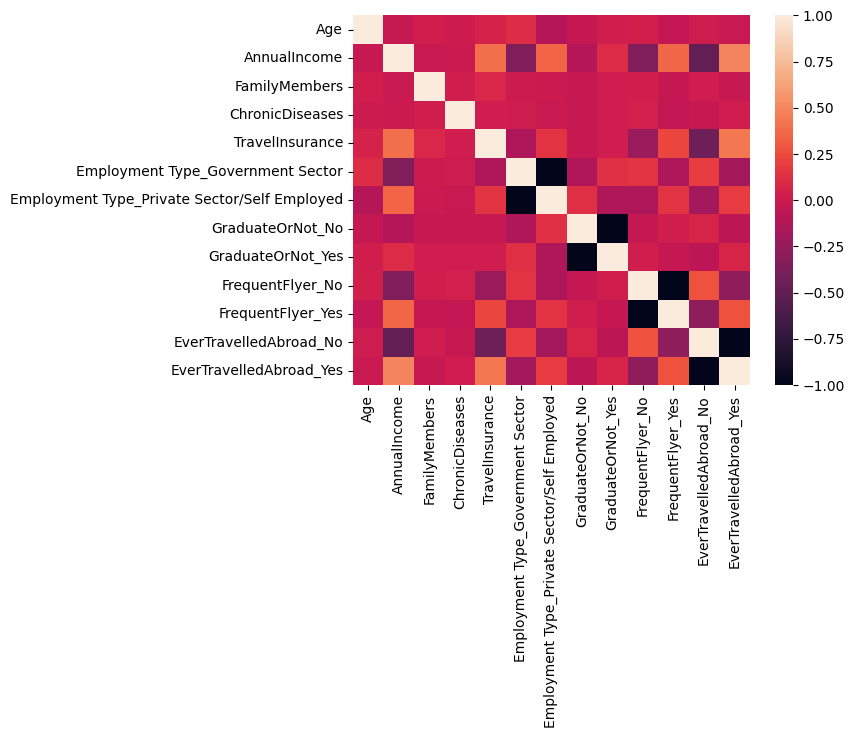

In [37]:
# Heatmap
import seaborn as sns

def apply_feature_engineering(df):
    """
    Apply all feature engineering to transform your data into number
    :param df: pandas DataFrame
    :return: pandas DataFrame
    """
    # Todo: Normalize your data
    df = pd.get_dummies(df, columns=['Employment Type', 'GraduateOrNot', 'FrequentFlyer', 'EverTravelledAbroad']).astype(int)
    return df

df = apply_feature_engineering(df)
sns.heatmap(df.corr()) # Show heatmap after normalized data

In [38]:
df.head()

,Age,AnnualIncome,FamilyMembers,ChronicDiseases,TravelInsurance,Employment Type_Government Sector,Employment Type_Private Sector/Self Employed,GraduateOrNot_No,GraduateOrNot_Yes,FrequentFlyer_No,FrequentFlyer_Yes,EverTravelledAbroad_No,EverTravelledAbroad_Yes
0,31,400000,6,1,0,1,0,0,1,1,0,1,0
1,31,1250000,7,0,0,0,1,0,1,1,0,1,0
2,34,500000,4,1,1,0,1,0,1,1,0,1,0
3,28,700000,3,1,0,0,1,0,1,1,0,1,0
4,28,700000,8,1,0,0,1,0,1,0,1,1,0


In [39]:
def prepare_X_y(df):
    """
    Feature engineering and create X and y
    :param df: pandas dataframe
    :return: (X, y) output feature matrix (dataframe), target (series)
    """
    # Todo: Split data into X and y (using sklearn train_test_split). Return two dataframes
    X = df.drop(columns=['TravelInsurance'])# Todo: Select features
    y = df['TravelInsurance']# Todo: Select label
    return X, y

X, y = prepare_X_y(df)

# Apply machine learning model

## Train-test split

In [40]:
from sklearn.model_selection import train_test_split
RANDOM_STATE = 42
TRAIN_SIZE = 0.8

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE)

## Build SK-learn model

In [50]:
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def build_model_DT(X, y):
    """
    Design your model and train it (including your best params)
    :param X: feature matrix
    :param y: target
    :return: a model
    """

    # Todo: Input your scaler and logistic model into pipeline
    model = DecisionTreeClassifier()
    
    # Parameters of pipelines can be set using '__' separated parameter names:
    param_grid = {
        # Tiêu chí để chia node: gini impurity, entropy (thông tin), hoặc log loss
        'criterion': ['gini', 'entropy', 'log_loss'],

        # Độ sâu tối đa của cây, giúp tránh overfitting
        'max_depth': [None, 5, 10, 20],

        # Số lượng mẫu tối thiểu để chia một node (nếu nhỏ hơn sẽ không chia nữa)
        'min_samples_split': [2, 5, 10],

        # Số lượng mẫu tối thiểu ở một leaf node (giúp tránh overfitting)
        'min_samples_leaf': [1, 2, 4],

        # Số lượng tối đa các feature được xem xét khi chia một node (giảm overfitting và tăng tốc)
        'max_features': [None, 'sqrt', 'log2'],

        # Trọng số lớp — hữu ích nếu dữ liệu mất cân bằng
        'class_weight': [None, 'balanced']
    }

    # Todo: fit your model with X, y
    search = GridSearchCV(model, param_grid, scoring="recall", cv=5, n_jobs=2)
    search.fit(X, y)

    print("Best parameter (CV score=%0.3f):" % search.best_score_)
    print(search.best_params_)

    best_model = search.best_estimator_
    return best_model

def build_model_RF(X, y):
    """
    Design your model and train it (including your best params)
    :param X: feature matrix
    :param y: target
    :return: a model
    """

    # Todo: Input your scaler and logistic model into pipeline
    model = RandomForestClassifier()
    
    # Parameters of pipelines can be set using '__' separated parameter names:
    param_grid = {
        # Tiêu chí để chia node: gini impurity, entropy (thông tin), hoặc log loss
        'criterion': ['gini', 'entropy', 'log_loss'],

        # Độ sâu tối đa của cây, giúp tránh overfitting
        'max_depth': [None, 5, 10, 20],

        # Số lượng mẫu tối thiểu để chia một node (nếu nhỏ hơn sẽ không chia nữa)
        'min_samples_split': [2, 5, 10],

        # Số lượng mẫu tối thiểu ở một leaf node (giúp tránh overfitting)
        'min_samples_leaf': [1, 2, 4],

        # Số lượng tối đa các feature được xem xét khi chia một node (giảm overfitting và tăng tốc)
        'max_features': [None, 'sqrt', 'log2'],

        # Trọng số lớp — hữu ích nếu dữ liệu mất cân bằng
        'class_weight': [None, 'balanced'],

        # Số lượng cây
        'n_estimators': [20, 50, 100, 200], 
    }

    # Todo: fit your model with X, y
    search = GridSearchCV(model, param_grid, scoring="recall", cv=5, n_jobs=2)
    search.fit(X, y)

    print("Best parameter (CV score=%0.3f):" % search.best_score_)
    print(search.best_params_)

    best_model = search.best_estimator_
    return best_model

def calculate_performance(y_true, y_pred):
    """

    :param y_true: ground truth values
    :param y_pred: predictions
    :return:
    """
    # Todo: return your error value like accuracy, f1score, ...
    print("precision", precision_score(y_true, y_pred) )
    print("recall", recall_score(y_true, y_pred))
    print("accuracy", accuracy_score(y_true, y_pred))
    print("F1", f1_score(y_true, y_pred))

    # Todo: Only choose one of them as your score for the question 7
    main_score = recall_score(y_true, y_pred)
    return main_score

In [72]:
model_DT = build_model_DT(X_train, y_train)
# Compare on training dataset
pred = model_DT.predict(X_test)
calculate_performance(y_test, pred)

print(classification_report(y_test, pred, digits=3))

Best parameter (CV score=0.699):
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10}
precision 0.7054263565891473
recall 0.6453900709219859
accuracy 0.7788944723618091
F1 0.674074074074074
              precision    recall  f1-score   support

           0      0.814     0.852     0.833       257
           1      0.705     0.645     0.674       141

    accuracy                          0.779       398
   macro avg      0.760     0.749     0.753       398
weighted avg      0.776     0.779     0.777       398



In [73]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(k_neighbors=5, random_state=0)
X_train_oversampling, y_train_oversampling = smote.fit_resample(X_train, y_train)

print(len(X_train), len(y_train))
print(len(X_train_oversampling), len(y_train_oversampling))

1589 1589
2040 2040


In [75]:
model_DT = build_model_DT(X_train_oversampling, y_train_oversampling)
# Compare on training dataset
pred = model_DT.predict(X_test)
calculate_performance(y_test, pred)

print(classification_report(y_test, pred, digits=3))

Best parameter (CV score=0.768):
{'class_weight': 'balanced', 'criterion': 'log_loss', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
precision 0.696969696969697
recall 0.6524822695035462
accuracy 0.7763819095477387
F1 0.673992673992674
              precision    recall  f1-score   support

           0      0.816     0.844     0.830       257
           1      0.697     0.652     0.674       141

    accuracy                          0.776       398
   macro avg      0.756     0.748     0.752       398
weighted avg      0.774     0.776     0.775       398



In [76]:
# Truy cập vào DecisionTreeClassifier trong pipeline
tree_model = model_DT

# Lấy độ quan trọng của từng feature
importances = tree_model.feature_importances_

# Lấy tên các feature
feature_names = df.columns.to_list()[:-1]

# Tìm feature có độ quan trọng cao nhất
most_important_index = importances.argmax()
most_important_feature = feature_names[most_important_index]
most_important_value = importances[most_important_index]

print(f"🔍 Feature quan trọng nhất: {most_important_feature} (importance = {most_important_value:.4f})")


🔍 Feature quan trọng nhất: AnnualIncome (importance = 0.2433)


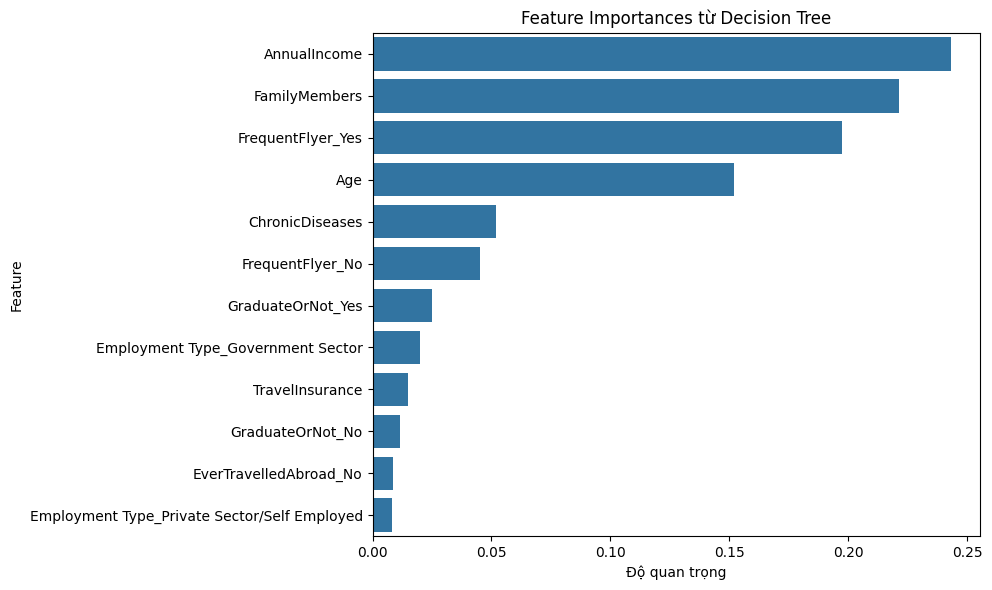

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tạo DataFrame chứa tên và độ quan trọng
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tree_model.feature_importances_
})

# Sắp xếp theo độ quan trọng giảm dần
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Importances từ Decision Tree")
plt.xlabel("Độ quan trọng")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [71]:
model_RF = build_model_RF(X_train, y_train)
# Compare on training dataset
pred = model_RF.predict(X_test)
calculate_performance(y_test, pred)

print(classification_report(y_test, pred, digits=3))

Best parameter (CV score=0.659):
{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 20}
precision 0.7459016393442623
recall 0.6453900709219859
accuracy 0.7964824120603015
F1 0.6920152091254753
              precision    recall  f1-score   support

           0      0.819     0.879     0.848       257
           1      0.746     0.645     0.692       141

    accuracy                          0.796       398
   macro avg      0.782     0.762     0.770       398
weighted avg      0.793     0.796     0.793       398



### 7:
**Main Metric**: My main metric is Recall. In predicting travel insurance purchases, failing to identify a potential buyer (False Negative) means a direct loss of potential revenue. Optimizing Recall ensures that our marketing efforts capture as many actual buyers as possible, which is more valuable for business growth than merely saving on marketing costs.
**Main model & Parameters**: The main model is a Random Forest Classifier. The optimized parameters and the reasoning behind them are as follows:
- class_weight: 'balanced': This is the most critical parameter here. It automatically adjusts weights inversely proportional to class frequencies, forcing the model to pay more attention to the minority class (Class 1).
- criterion: 'entropy': Uses information gain to determine the best splits, which can sometimes lead to more balanced trees than the default 'gini'.
- max_depth: 20: Allows the trees to grow deep enough to capture complex patterns in the data while still providing a limit to prevent extreme overfitting.
- n_estimators: 20: This indicates that a forest of 20 trees provided the best Cross-Validation (CV) score of 0.659, balancing computational efficiency with predictive power.
- max_features: 'log2': Limits the number of features considered at each split, which helps in reducing the correlation between trees and increasing the diversity of the forest.
- min_samples_split: 5 and min_samples_leaf: 1: These control the growth of the trees to ensure the model captures specific patterns while maintaining statistical significance in its predictions.